# Clustering de Forma — Piezas Rotational

**Estrategia B (jerárquica):** clusterizamos solo las ~252 piezas `rotational` que representan el 87% del pipeline. Los demás (`complex_3d`, `plate`, `prismatic`) quedan fuera de este análisis.

**Feature set limpio (12):** descartamos las 7 features inútiles detectadas en la exploración (3 caras siempre 0, 2 conteos siempre 0, 2 duplicados).

**Pipeline:**
1. Cargar datos + filtrar a rotational
2. Construir feature set final (drop constantes/duplicados, log1p a angled_hole_count)
3. Imputar nulos remanentes + StandardScaler + one-hot `axis_recommendation`
4. PCA — varianza explicada
5. Visualización 2D (PCA + t-SNE)
6. Elegir k: elbow + silhouette
7. KMeans con k óptimo
8. Alternativa: HDBSCAN
9. Perfiles de cluster: centroides, piezas representativas
10. Validación kNN: leave-one-out sobre precio (MAPE)
11. Guardar asignaciones

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.neighbors import NearestNeighbors

try:
    from sklearn.cluster import HDBSCAN
    HDBSCAN_AVAILABLE = True
except ImportError:
    HDBSCAN_AVAILABLE = False
    print('HDBSCAN no disponible (requiere sklearn >= 1.3). Se omitirá.')

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')
np.random.seed(42)

## 1. Cargar y filtrar a rotational

In [2]:
df = pd.read_parquet('manufacturing_quotes_clean.parquet')
print(f'Dataset completo: {df.shape}')

df_rot = df[df['part_type'] == 'rotational'].copy().reset_index(drop=True)
print(f'Solo rotational: {df_rot.shape}')
print(df_rot['part_type'].value_counts(dropna=False))

Dataset completo: (297, 46)
Solo rotational: (252, 46)
part_type
rotational    252
Name: count, dtype: int64


## 2. Feature set final

De los 19 shape features originales, descartamos:
- Constantes: `face_orientation_*.X-_pct`, `Y-_pct`, `Z-_pct`, `undercut_count`, `inaccessible_feature_count`
- Duplicados: `min_setups_3axis` (≡ `direction_count`), `bbox_ratio_3` (r=0.97 con `thin_ratio` — conservamos `bbox_ratio_3` por ser geométricamente más directo; dropeamos `thin_ratio`)

Además: `angled_hole_count` es muy skewed → aplicamos `log1p`.

In [3]:
SHAPE_NUMERIC = [
    'aspect_ratio',
    'plane_ratio', 'cyl_ratio', 'complex_ratio',
    'material_removal_pct',
    'bbox_ratio_2', 'bbox_ratio_3',
    'face_orientation_distribution.X+_pct',
    'face_orientation_distribution.Y+_pct',
    'face_orientation_distribution.Z+_pct',
    'direction_count',
    'angled_hole_count',
]
SHAPE_CATEGORICAL = ['axis_recommendation']

# log1p a angled_hole_count (in-place como nueva columna)
df_rot['angled_hole_count_log'] = np.log1p(df_rot['angled_hole_count'])
SHAPE_NUMERIC = [c if c != 'angled_hole_count' else 'angled_hole_count_log' for c in SHAPE_NUMERIC]

# Sanity check
missing = [c for c in SHAPE_NUMERIC + SHAPE_CATEGORICAL if c not in df_rot.columns]
print(f'Columnas faltantes: {missing}')
print(f'\nFeatures numéricos ({len(SHAPE_NUMERIC)}):')
for c in SHAPE_NUMERIC:
    print(f'  {c}')
print(f'\nFeatures categóricos: {SHAPE_CATEGORICAL}')

Columnas faltantes: []

Features numéricos (12):
  aspect_ratio
  plane_ratio
  cyl_ratio
  complex_ratio
  material_removal_pct
  bbox_ratio_2
  bbox_ratio_3
  face_orientation_distribution.X+_pct
  face_orientation_distribution.Y+_pct
  face_orientation_distribution.Z+_pct
  direction_count
  angled_hole_count_log

Features categóricos: ['axis_recommendation']


## 3. Preprocess: impute + scale + one-hot

In [4]:
# Contamos nulos
print('Nulos en feature set:')
print(df_rot[SHAPE_NUMERIC + SHAPE_CATEGORICAL].isna().sum()[lambda s: s > 0].to_string())

# Imputamos numéricos con mediana (pocos nulos)
num_imputer = SimpleImputer(strategy='median')
X_num = num_imputer.fit_transform(df_rot[SHAPE_NUMERIC])

# Scale
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)

# One-hot a categóricas (tratamos NaN como categoría propia)
df_rot[SHAPE_CATEGORICAL] = df_rot[SHAPE_CATEGORICAL].fillna('unknown')
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_cat = ohe.fit_transform(df_rot[SHAPE_CATEGORICAL])
cat_feature_names = ohe.get_feature_names_out(SHAPE_CATEGORICAL).tolist()

# Concatenamos
X = np.hstack([X_num_scaled, X_cat])
FEATURE_NAMES = SHAPE_NUMERIC + cat_feature_names
print(f'\nMatriz final X: {X.shape} ({len(FEATURE_NAMES)} features)')
print(f'Features: {FEATURE_NAMES}')

Nulos en feature set:
bbox_ratio_2                            3
bbox_ratio_3                            3
face_orientation_distribution.X+_pct    3
face_orientation_distribution.Y+_pct    3
face_orientation_distribution.Z+_pct    3
direction_count                         3
angled_hole_count_log                   3
axis_recommendation                     3

Matriz final X: (252, 16) (16 features)
Features: ['aspect_ratio', 'plane_ratio', 'cyl_ratio', 'complex_ratio', 'material_removal_pct', 'bbox_ratio_2', 'bbox_ratio_3', 'face_orientation_distribution.X+_pct', 'face_orientation_distribution.Y+_pct', 'face_orientation_distribution.Z+_pct', 'direction_count', 'angled_hole_count_log', 'axis_recommendation_3-axis             ', 'axis_recommendation_4-axis             ', 'axis_recommendation_5-axis             ', 'axis_recommendation_unknown']


## 4. PCA — varianza explicada

¿Cuántos componentes necesitamos para capturar la estructura? Si los primeros 2-3 PCs explican >70%, el clustering en 2D tendrá sentido directo.

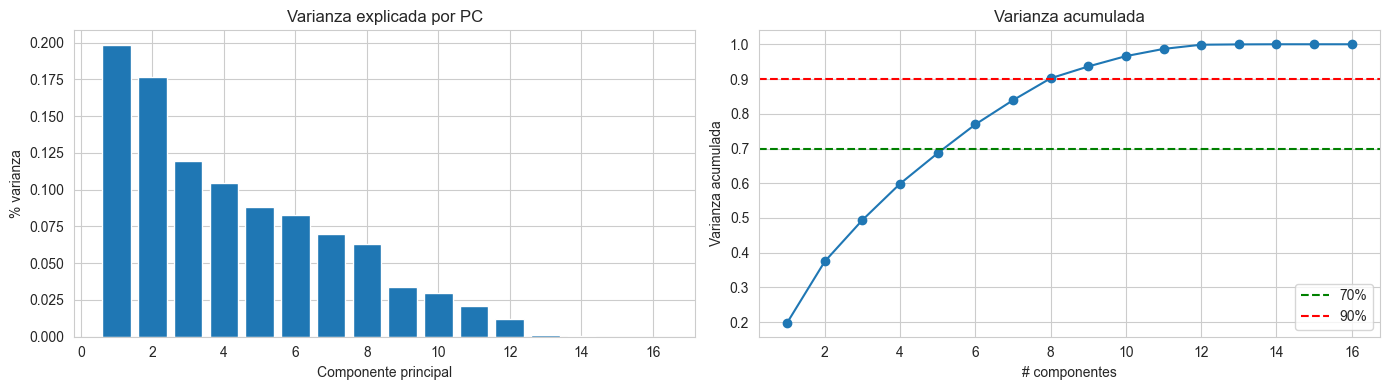

2 PCs: 37.5%
3 PCs: 49.4%
5 PCs: 68.7%
7 PCs: 83.9%


In [5]:
pca = PCA()
X_pca = pca.fit_transform(X)

cum_var = np.cumsum(pca.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_)
axes[0].set_xlabel('Componente principal')
axes[0].set_ylabel('% varianza')
axes[0].set_title('Varianza explicada por PC')

axes[1].plot(range(1, len(cum_var) + 1), cum_var, marker='o')
axes[1].axhline(0.7, color='g', ls='--', label='70%')
axes[1].axhline(0.9, color='r', ls='--', label='90%')
axes[1].set_xlabel('# componentes')
axes[1].set_ylabel('Varianza acumulada')
axes[1].set_title('Varianza acumulada')
axes[1].legend()
plt.tight_layout()
plt.show()

print(f'2 PCs: {cum_var[1]*100:.1f}%')
print(f'3 PCs: {cum_var[2]*100:.1f}%')
print(f'5 PCs: {cum_var[4]*100:.1f}%')
print(f'7 PCs: {cum_var[6]*100:.1f}%')

Loadings de los primeros 4 PCs:
                                           PC1    PC2    PC3    PC4
aspect_ratio                            -0.408 -0.136  0.373  0.022
plane_ratio                              0.102  0.417 -0.164 -0.342
cyl_ratio                               -0.298  0.100 -0.355 -0.122
complex_ratio                            0.355 -0.214  0.140  0.006
material_removal_pct                     0.174 -0.409 -0.084  0.131
bbox_ratio_2                             0.012 -0.412 -0.340  0.154
bbox_ratio_3                             0.463 -0.130 -0.373  0.031
face_orientation_distribution.X+_pct     0.052  0.353 -0.278  0.573
face_orientation_distribution.Y+_pct     0.413 -0.003  0.442 -0.266
face_orientation_distribution.Z+_pct    -0.424 -0.301 -0.167 -0.253
direction_count                          0.047  0.375 -0.132 -0.286
angled_hole_count_log                    0.080 -0.193 -0.230 -0.479
axis_recommendation_3-axis              -0.030  0.053  0.163  0.153
axis_recommendat

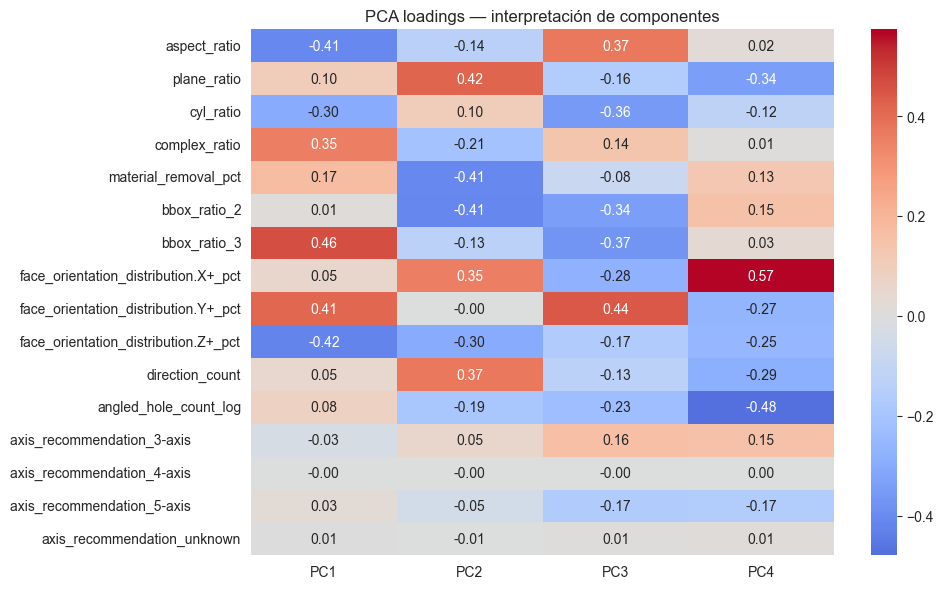

In [6]:
# Loadings — qué features dominan cada PC
loadings = pd.DataFrame(
    pca.components_[:4].T,
    index=FEATURE_NAMES,
    columns=[f'PC{i+1}' for i in range(4)],
)
print('Loadings de los primeros 4 PCs:')
print(loadings.round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(loadings, cmap='coolwarm', center=0, annot=True, fmt='.2f', ax=ax)
ax.set_title('PCA loadings — interpretación de componentes')
plt.tight_layout()
plt.show()

## 5. Visualización 2D (PCA + t-SNE)

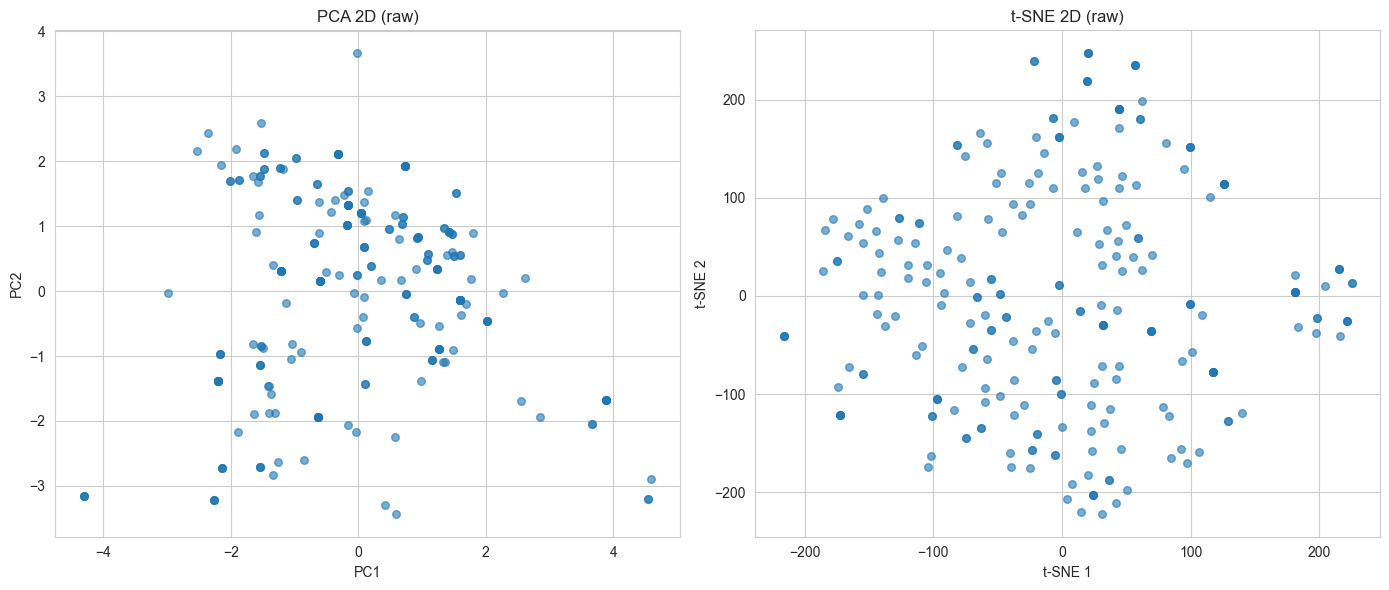

In [7]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca')
X_tsne = tsne.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, s=30)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('PCA 2D (raw)')

axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.6, s=30)
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].set_title('t-SNE 2D (raw)')
plt.tight_layout()
plt.show()

## 6. Elegir k — elbow + silhouette

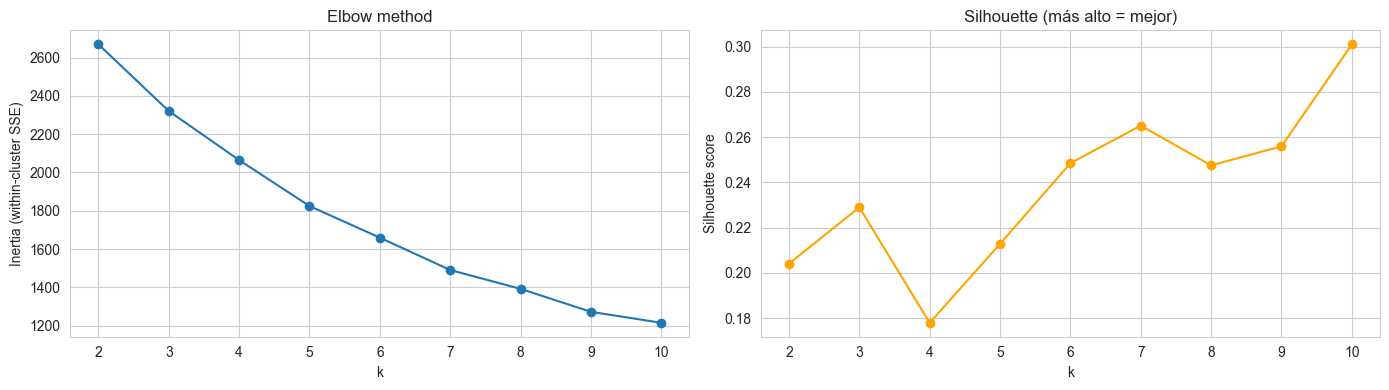

k=2: silhouette=0.204
k=3: silhouette=0.229
k=4: silhouette=0.178
k=5: silhouette=0.213
k=6: silhouette=0.249
k=7: silhouette=0.265
k=8: silhouette=0.248
k=9: silhouette=0.256
k=10: silhouette=0.301

Mejor k por silhouette: 10


In [8]:
ks = range(2, 11)
inertias = []
silhouettes = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(list(ks), inertias, marker='o')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia (within-cluster SSE)')
axes[0].set_title('Elbow method')
axes[0].grid(True)

axes[1].plot(list(ks), silhouettes, marker='o', color='orange')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette (más alto = mejor)')
axes[1].grid(True)
plt.tight_layout()
plt.show()

for k, s in zip(ks, silhouettes):
    print(f'k={k}: silhouette={s:.3f}')

best_k = list(ks)[int(np.argmax(silhouettes))]
print(f'\nMejor k por silhouette: {best_k}')

## 7. KMeans final

Nota: el mejor k por silhouette puede ser bajo (2-3) por tratarse de un dataset con un "blob" dominante. A veces conviene fijar k un poco mayor (ej. 4-6) para obtener segmentación más accionable aunque el score sea algo menor. Ajusta `K_FINAL` abajo si el resultado no es satisfactorio.

In [9]:
K_FINAL = 5  # cambiar manualmente si se quiere forzar otro valor (ej. 5)

kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=50)
df_rot['cluster'] = kmeans.fit_predict(X)

print(f'k = {K_FINAL}')
print(f'Silhouette: {silhouette_score(X, df_rot["cluster"]):.3f}')
print(f'\nTamaños de cluster:')
print(df_rot['cluster'].value_counts().sort_index().to_string())

k = 5
Silhouette: 0.214

Tamaños de cluster:
cluster
0    60
1    32
2    69
3    71
4    20


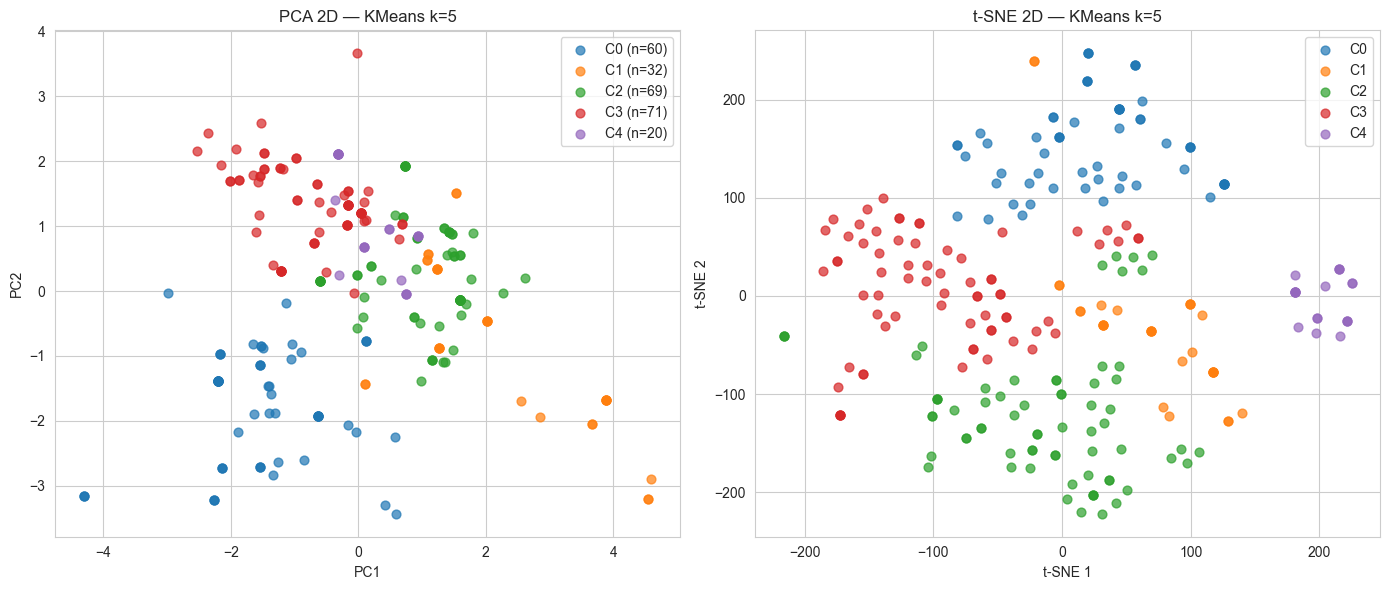

In [10]:
# Visualizamos los clusters en PCA y t-SNE
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
palette = sns.color_palette('tab10', K_FINAL)

for c in range(K_FINAL):
    mask = df_rot['cluster'] == c
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], s=40, alpha=0.7, color=palette[c], label=f'C{c} (n={mask.sum()})')
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1], s=40, alpha=0.7, color=palette[c], label=f'C{c}')

axes[0].set_title(f'PCA 2D — KMeans k={K_FINAL}')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2'); axes[0].legend()
axes[1].set_title(f't-SNE 2D — KMeans k={K_FINAL}')
axes[1].set_xlabel('t-SNE 1'); axes[1].set_ylabel('t-SNE 2'); axes[1].legend()
plt.tight_layout()
plt.show()

## 8. Alternativa: HDBSCAN

HDBSCAN no requiere fijar k y detecta outliers (los marca como cluster `-1`).

HDBSCAN: 5 clusters, 127 outliers (50.4%)

Tamaños:
-1    127
 0     20
 1     13
 2     12
 3     68
 4     12


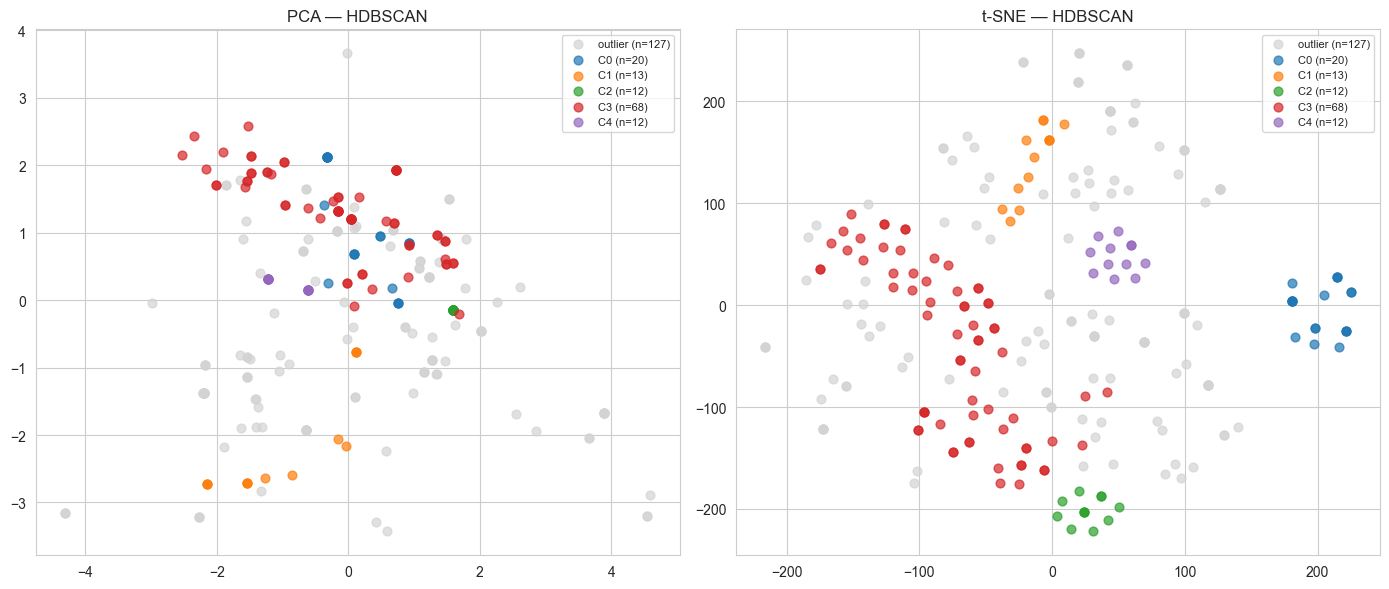

In [11]:
if HDBSCAN_AVAILABLE:
    hdb = HDBSCAN(min_cluster_size=10, min_samples=5)
    hdb_labels = hdb.fit_predict(X)
    df_rot['hdbscan_cluster'] = hdb_labels
    
    n_clusters = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
    n_outliers = (hdb_labels == -1).sum()
    print(f'HDBSCAN: {n_clusters} clusters, {n_outliers} outliers ({n_outliers/len(hdb_labels)*100:.1f}%)')
    print(f'\nTamaños:')
    print(pd.Series(hdb_labels).value_counts().sort_index().to_string())
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    palette_h = sns.color_palette('tab10', max(n_clusters, 1))
    for c in sorted(set(hdb_labels)):
        mask = hdb_labels == c
        color = 'lightgray' if c == -1 else palette_h[c % len(palette_h)]
        label = f'outlier (n={mask.sum()})' if c == -1 else f'C{c} (n={mask.sum()})'
        axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], s=40, alpha=0.7, color=color, label=label)
        axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1], s=40, alpha=0.7, color=color, label=label)
    axes[0].set_title('PCA — HDBSCAN'); axes[0].legend(fontsize=8)
    axes[1].set_title('t-SNE — HDBSCAN'); axes[1].legend(fontsize=8)
    plt.tight_layout()
    plt.show()

## 9. Perfiles de cluster — ¿qué tipo de pieza es cada uno?

In [12]:
# Medianas por cluster (numéricas shape) + contexto (tamaño y precio)
PROFILE_COLS = SHAPE_NUMERIC + ['part_volume_cm3', 'weight_g', 'total_holes', 'faces_qty', 'unit_price']
PROFILE_COLS = [c for c in PROFILE_COLS if c in df_rot.columns]

profiles = df_rot.groupby('cluster')[PROFILE_COLS].median()
profiles['count'] = df_rot['cluster'].value_counts().sort_index()
profiles = profiles[['count'] + [c for c in profiles.columns if c != 'count']]
print('Mediana de features por cluster:')
print(profiles.round(2).to_string())

Mediana de features por cluster:
         count  aspect_ratio  plane_ratio  cyl_ratio  complex_ratio  material_removal_pct  bbox_ratio_2  bbox_ratio_3  face_orientation_distribution.X+_pct  face_orientation_distribution.Y+_pct  face_orientation_distribution.Z+_pct  direction_count  angled_hole_count_log  part_volume_cm3  weight_g  total_holes  faces_qty  unit_price
cluster                                                                                                                                                                                                                                                                                                                                       
0           60          5.90         0.14       0.55            0.0                 85.60          1.00          0.17                                  0.00                                  0.00                                  1.00              1.0                    0.0            57.76    361.5

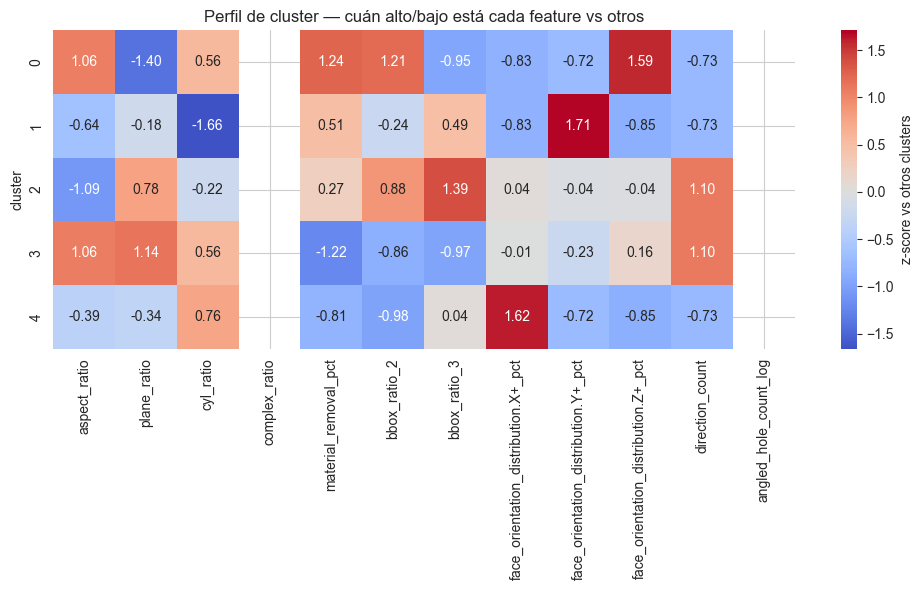

In [13]:
# Heatmap de perfiles normalizados (z-score) para ver qué distingue a cada cluster
shape_profile = df_rot.groupby('cluster')[SHAPE_NUMERIC].median()
shape_profile_z = (shape_profile - shape_profile.mean()) / shape_profile.std()

fig, ax = plt.subplots(figsize=(10, K_FINAL * 0.8 + 2))
sns.heatmap(shape_profile_z, cmap='coolwarm', center=0, annot=True, fmt='.2f',
            cbar_kws={'label': 'z-score vs otros clusters'}, ax=ax)
ax.set_title('Perfil de cluster — cuán alto/bajo está cada feature vs otros')
plt.tight_layout()
plt.show()

In [14]:
# Piezas representativas por cluster: las 5 más cercanas al centroide
centroids = kmeans.cluster_centers_
reps_per_cluster = {}
for c in range(K_FINAL):
    mask = df_rot['cluster'] == c
    dists = np.linalg.norm(X[mask] - centroids[c], axis=1)
    idx = df_rot[mask].index[np.argsort(dists)[:5]]
    reps_per_cluster[c] = idx.tolist()
    
    print(f'\n=== Cluster {c} (n={mask.sum()}) — 5 piezas representativas ===')
    cols_show = ['product_name', 'aspect_ratio', 'cyl_ratio', 'plane_ratio',
                 'bbox_ratio_2', 'bbox_ratio_3', 'part_volume_cm3', 'unit_price',
                 'material_title', 'axis_recommendation']
    cols_show = [c for c in cols_show if c in df_rot.columns]
    print(df_rot.loc[idx, cols_show].to_string())


=== Cluster 0 (n=60) — 5 piezas representativas ===
                                                     product_name  aspect_ratio  cyl_ratio  plane_ratio  bbox_ratio_2  bbox_ratio_3  part_volume_cm3  unit_price             material_title  axis_recommendation
5    V-10033460AC-000244-009_000_00                                        3.16      0.580        0.126      0.994660      0.316069          4745.28   3728.8251  steel_grade_A2             3-axis             
242  Disco                                                                14.00      0.593        0.111      0.964102      0.071439            58.88     95.6800  aluminum_6061              3-axis             
241  Disco                                                                14.00      0.593        0.111      0.964102      0.071439            58.88    250.0000  aluminum_6061              3-axis             
243  Disco                                                                14.00      0.593        0.111      0.

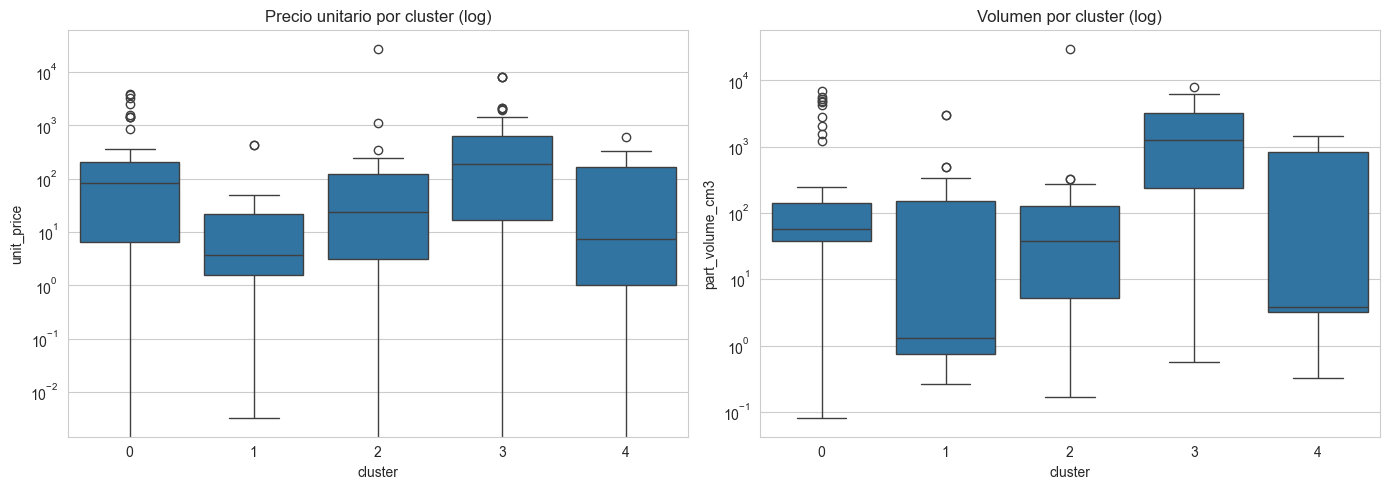

In [15]:
# Distribución de precio y tamaño por cluster
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_rot, x='cluster', y='unit_price', ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('Precio unitario por cluster (log)')

sns.boxplot(data=df_rot, x='cluster', y='part_volume_cm3', ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('Volumen por cluster (log)')
plt.tight_layout()
plt.show()

## 10. Validación kNN — ¿los clusters predicen precio?

Leave-one-out: para cada pieza, buscamos sus k vecinos más cercanos en el espacio de forma, predecimos su precio con la mediana de los vecinos, y medimos el error. Comparamos contra un baseline simple (mediana global).

**Importante:** el precio depende de tamaño y material (que NO están en el espacio de forma). El kNN aquí es solo sobre forma, así que esperamos error alto. La pregunta es: ¿hace mejor que el baseline?

In [16]:
prices = df_rot['unit_price'].values
valid = ~np.isnan(prices)
X_valid = X[valid]
prices_valid = prices[valid]

def loo_knn_predict(X, y, k):
    nn = NearestNeighbors(n_neighbors=k + 1).fit(X)  # +1 porque el primero es el mismo punto
    _, idx = nn.kneighbors(X)
    preds = np.array([np.median(y[idx[i, 1:]]) for i in range(len(X))])
    return preds

results = []
for k in [1, 3, 5, 10, 20]:
    preds = loo_knn_predict(X_valid, prices_valid, k)
    mape = np.mean(np.abs(preds - prices_valid) / prices_valid) * 100
    mae = np.mean(np.abs(preds - prices_valid))
    results.append({'k': k, 'MAPE_%': mape, 'MAE_USD': mae})

# Baseline: mediana global
baseline_pred = np.median(prices_valid)
baseline_mape = np.mean(np.abs(baseline_pred - prices_valid) / prices_valid) * 100
baseline_mae = np.mean(np.abs(baseline_pred - prices_valid))
results.append({'k': 'baseline_median', 'MAPE_%': baseline_mape, 'MAE_USD': baseline_mae})

print(pd.DataFrame(results).to_string(index=False))

              k  MAPE_%    MAE_USD
              1     inf 341.365738
              3     inf 265.214338
              5     inf 396.672214
             10     inf 377.014835
             20     inf 413.865036
baseline_median     inf 438.579921


C:\Users\Imanol\AppData\Local\Temp\ipykernel_28784\2514779582.py:15: RuntimeWarning: divide by zero encountered in divide
  mape = np.mean(np.abs(preds - prices_valid) / prices_valid) * 100
C:\Users\Imanol\AppData\Local\Temp\ipykernel_28784\2514779582.py:15: RuntimeWarning: divide by zero encountered in divide
  mape = np.mean(np.abs(preds - prices_valid) / prices_valid) * 100
C:\Users\Imanol\AppData\Local\Temp\ipykernel_28784\2514779582.py:15: RuntimeWarning: divide by zero encountered in divide
  mape = np.mean(np.abs(preds - prices_valid) / prices_valid) * 100
C:\Users\Imanol\AppData\Local\Temp\ipykernel_28784\2514779582.py:15: RuntimeWarning: divide by zero encountered in divide
  mape = np.mean(np.abs(preds - prices_valid) / prices_valid) * 100
C:\Users\Imanol\AppData\Local\Temp\ipykernel_28784\2514779582.py:15: RuntimeWarning: divide by zero encountered in divide
  mape = np.mean(np.abs(preds - prices_valid) / prices_valid) * 100
C:\Users\Imanol\AppData\Local\Temp\ipykernel_28784

In [17]:
# Baseline alternativo: predecir con la mediana del cluster al que pertenece
cluster_median_price = df_rot.groupby('cluster')['unit_price'].median()
pred_cluster = df_rot['cluster'].map(cluster_median_price).values

mask = ~np.isnan(prices) & ~np.isnan(pred_cluster)
mape_cluster = np.mean(np.abs(pred_cluster[mask] - prices[mask]) / prices[mask]) * 100
mae_cluster = np.mean(np.abs(pred_cluster[mask] - prices[mask]))
print(f'Baseline por cluster (mediana intra-cluster): MAPE={mape_cluster:.1f}%, MAE=${mae_cluster:.2f}')

Baseline por cluster (mediana intra-cluster): MAPE=inf%, MAE=$429.95


C:\Users\Imanol\AppData\Local\Temp\ipykernel_28784\2890147268.py:6: RuntimeWarning: divide by zero encountered in divide
  mape_cluster = np.mean(np.abs(pred_cluster[mask] - prices[mask]) / prices[mask]) * 100


## 11. Guardar asignaciones

In [ ]:
df_rot.to_parquet('rotational_with_clusters.parquet', index=False)
df_rot.to_csv('rotational_with_clusters.csv', index=False)

# Resumen compacto para inspección
summary = df_rot.groupby('cluster').agg(
    count=('cluster', 'size'),
    median_price=('unit_price', 'median'),
    median_volume=('part_volume_cm3', 'median'),
    median_aspect=('aspect_ratio', 'median'),
    median_cyl=('cyl_ratio', 'median'),
    median_plane=('plane_ratio', 'median'),
    median_bbox_ratio_3=('bbox_ratio_3', 'median'),
).round(2)
summary.to_csv('cluster_summary.csv')
print('Guardados: rotational_with_clusters.(parquet|csv), cluster_summary.csv')
print('\nResumen:')
print(summary.to_string())

## Próximos pasos (fase 2)

Según los resultados del cluster profiling + validación kNN:

1. **Si los clusters se ven bien definidos:** etiquetarlos manualmente (ej. "eje corto", "shaft largo", "disco plano rotacional", etc.) y documentar.
2. **Dentro de cada cluster:** sub-segmentar por tamaño (cuantiles de `log(part_volume_cm3)`).
3. **Modelo de costo por cluster:** regresión simple `price ~ volume + weight + material + tolerance_tier` entrenada por cluster. Con ~50 piezas/cluster es suficiente.
4. **Extender a no-rotational:** repetir el ejercicio con `complex_3d + plate` (43 piezas) si hay interés, aunque la muestra es más chica.
5. **Pipeline de inferencia:** para un RFQ nuevo → extraer features → predecir cluster (KMeans predict) → estimar precio por regresión del cluster o kNN.